# CSV Data Exploration

This notebook loads two CSV files and performs basic exploratory analysis and visualization.

## Setup

Import common data analysis and visualization libraries.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")

## Load CSV files

Update the folder path if your CSV files are stored elsewhere.

In [17]:
data_dir = Path(r".\20260203-1")
src_candidates = sorted(data_dir.glob("*_srcE_t_matrix.csv"))
det_candidates = sorted(data_dir.glob("*_detE_t_matrix.csv"))

if not src_candidates or not det_candidates:
    raise FileNotFoundError(
        f"Missing *_srcE_t_matrix.csv or *_detE_t_matrix.csv in {data_dir.resolve()}"
    )

src_path = src_candidates[0]
det_path = det_candidates[0]

src_path, det_path

(WindowsPath('20260203-1/tgf_srcE_t_matrix.csv'),
 WindowsPath('20260203-1/tgf_detE_t_matrix.csv'))

## Quick overview

Load the matrix CSVs and print basic ranges.

In [18]:
def load_matrix_csv(path: Path):
    df = pd.read_csv(path)
    if df.shape[1] < 2:
        raise ValueError(f"Matrix CSV has <2 columns: {path}")
    time_ns = df.iloc[:, 0].to_numpy(dtype=float)
    energy_mev = np.array([float(c) for c in df.columns[1:]], dtype=float)
    counts = df.iloc[:, 1:].to_numpy(dtype=float)
    return time_ns, energy_mev, counts

matrices = {}
for label, path in {"srcE_t": src_path, "detE_t": det_path}.items():
    time_ns, energy_mev, counts = load_matrix_csv(path)
    matrices[label] = (time_ns, energy_mev, counts)
    print(
        f"{label}: shape={counts.shape}, "
        f"time(ns)=[{time_ns.min():.3g}, {time_ns.max():.3g}], "
        f"E(MeV)=[{energy_mev.min():.3g}, {energy_mev.max():.3g}]"
    )


srcE_t: shape=(10000, 400), time(ns)=[2.5, 5e+04], E(MeV)=[0.05, 40]
detE_t: shape=(10000, 400), time(ns)=[2.5, 5e+04], E(MeV)=[0.05, 40]


## Time-resolved spectra plots

Plot the time-energy matrix and basic projections.

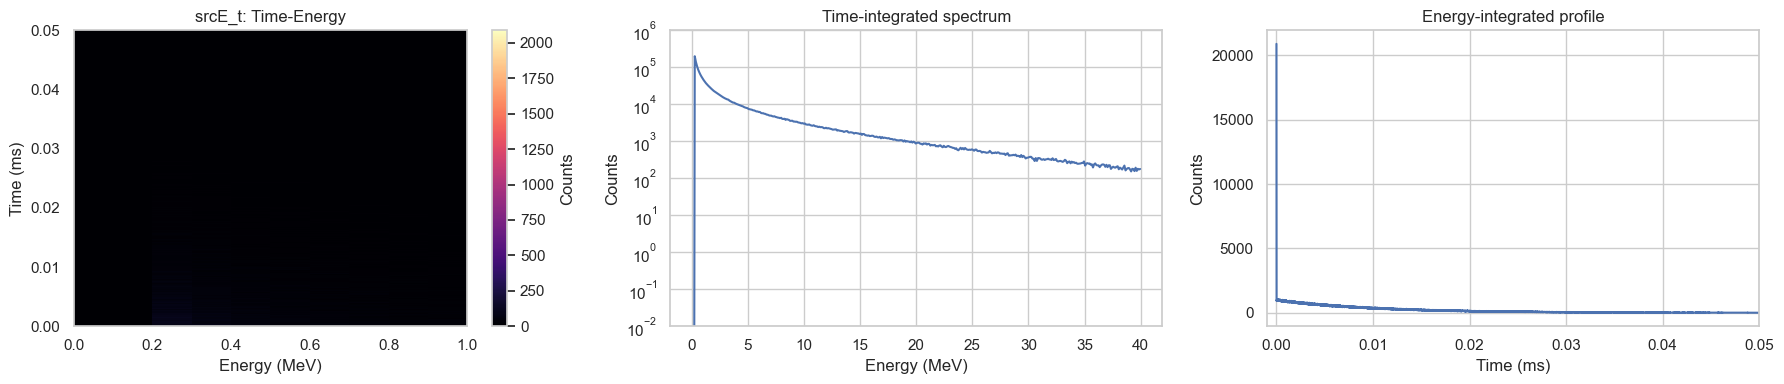

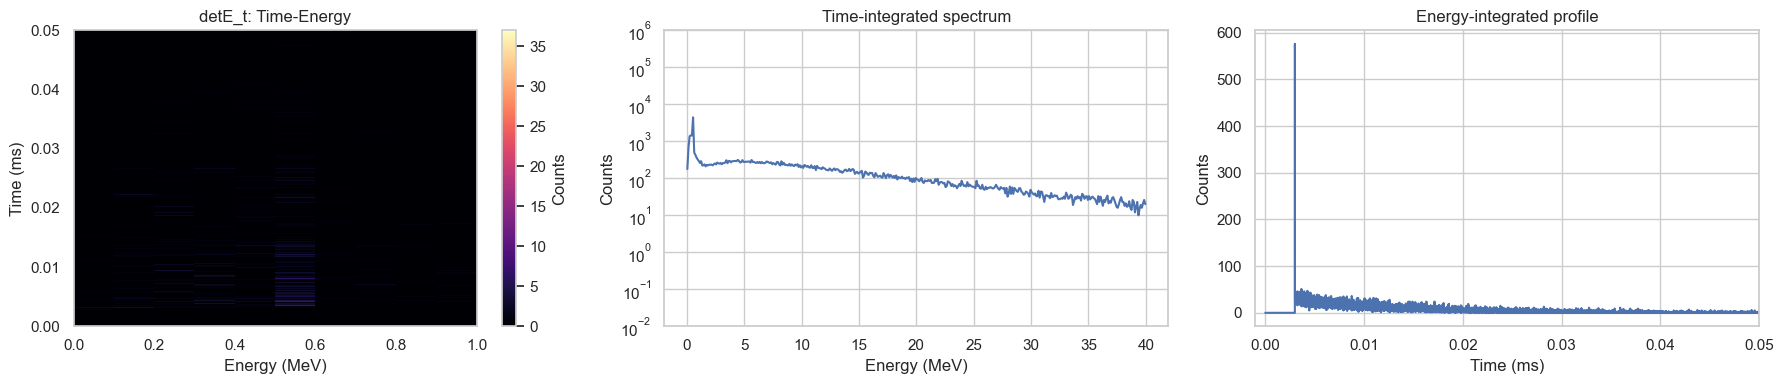

In [19]:
def plot_matrix(label, time_ns, energy_mev, counts):
    time_ms = time_ns * 1e-6

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    mesh = axes[0].pcolormesh(energy_mev, time_ms, counts, shading="auto", cmap="magma")
    axes[0].set_title(f"{label}: Time-Energy")
    axes[0].set_xlabel("Energy (MeV)")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 0.05)
    axes[0].set_ylabel("Time (ms)")
    fig.colorbar(mesh, ax=axes[0], label="Counts")

    energy_spectrum = counts.sum(axis=0)
    axes[1].semilogy(energy_mev, energy_spectrum + 1e-12)
    axes[1].set_title("Time-integrated spectrum")
    axes[1].set_xlabel("Energy (MeV)")
    axes[1].set_ylim(1e-2, 10**6)
    axes[1].set_ylabel("Counts")

    time_profile = counts.sum(axis=1)
    axes[2].plot(time_ms, time_profile)
    axes[2].set_title("Energy-integrated profile")
    axes[2].set_xlabel("Time (ms)")
    axes[2].set_xlim(-0.001, 0.05)
    axes[2].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

for label, (time_ns, energy_mev, counts) in matrices.items():
    plot_matrix(label, time_ns, energy_mev, counts)

## Comparison plots

Overlay source vs detector projections (normalized).

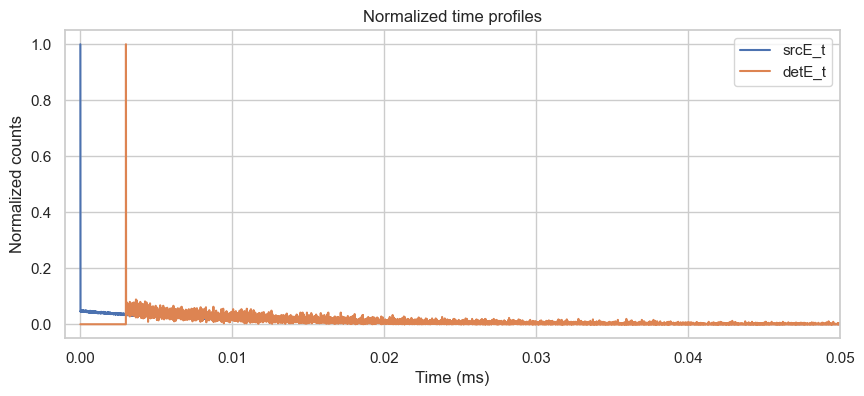

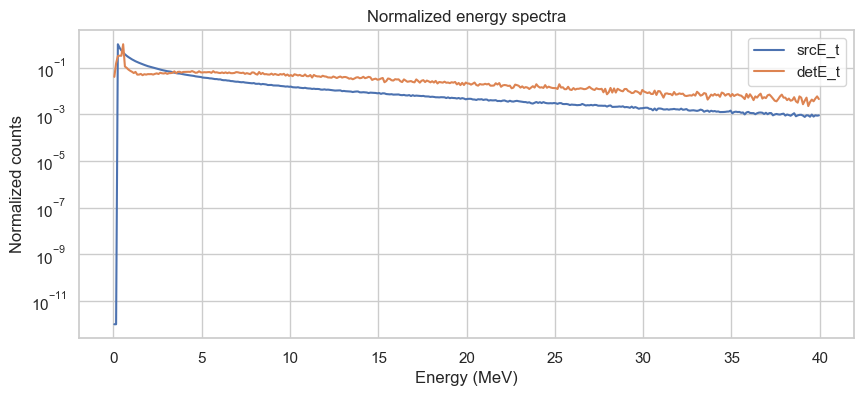

In [20]:
plt.figure(figsize=(10, 4))
for label, (time_ns, energy_mev, counts) in matrices.items():
    time_ms = time_ns * 1e-6
    profile = counts.sum(axis=1)
    if profile.max() > 0:
        profile = profile / profile.max()
    plt.plot(time_ms, profile, label=label)
plt.title("Normalized time profiles")
plt.xlabel("Time (ms)")
plt.ylabel("Normalized counts")
plt.xlim(-0.001, 0.05)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for label, (time_ns, energy_mev, counts) in matrices.items():
    spectrum = counts.sum(axis=0)
    if spectrum.max() > 0:
        spectrum = spectrum / spectrum.max()
    plt.semilogy(energy_mev, spectrum + 1e-12, label=label)
plt.title("Normalized energy spectra")
plt.xlabel("Energy (MeV)")
plt.ylabel("Normalized counts")
plt.legend()
plt.show()